Mean displacement per step: 6.212754552254252
Assumed erosion rate: 0.1 map units/year
Estimated years per model step: 62.12754552254252
Total modeled time: 18638.263656762756 years


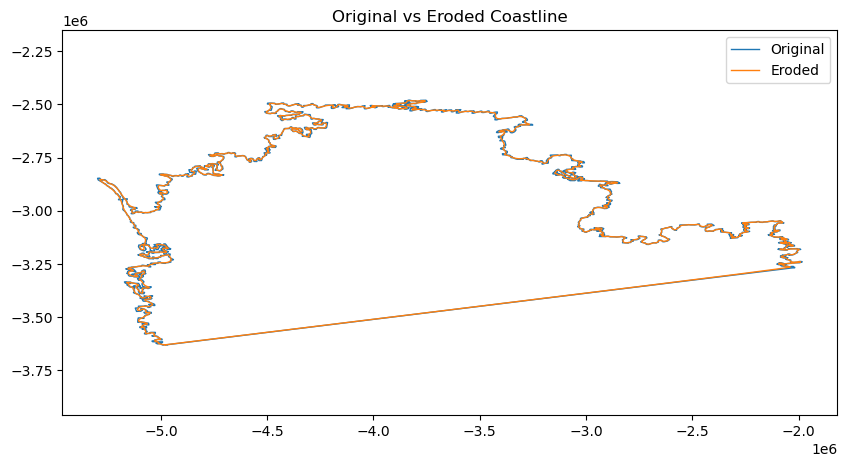

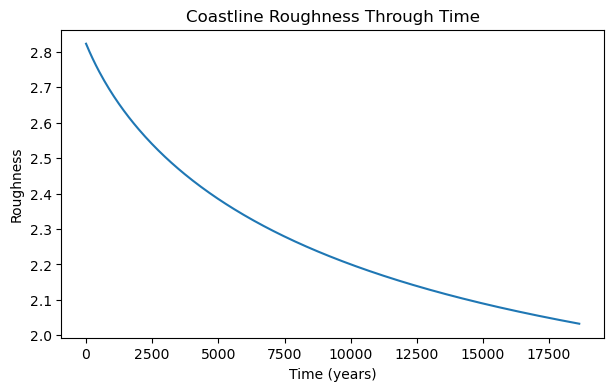

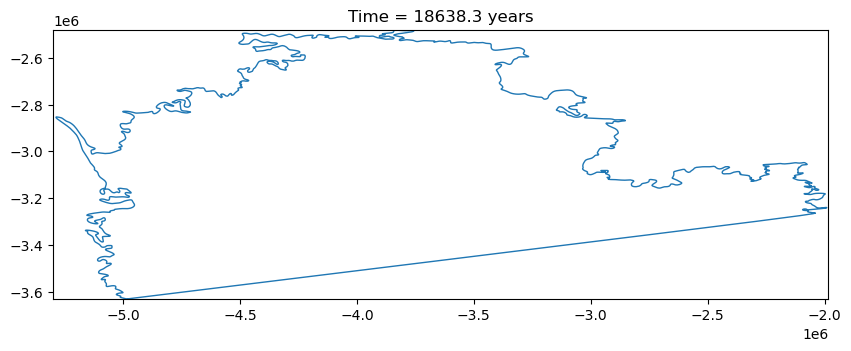

In [7]:
#with time involved?
# -----------------------
# 2. Get all coords for stretch/flip plotting
# -----------------------
all_coords = np.vstack([np.array(g.coords) for g in gdf.geometry])
all_y = all_coords[:, 1]

stretch = 9
y_mean = all_y.mean()

def transform_coords(x, y):
    y_stretched = (y - y_mean) * stretch + y_mean
    x_plot = -y_stretched
    y_plot = x
    return x_plot, y_plot

# -----------------------
# 3. Extract longest coastline
# -----------------------
coastline = max(gdf.geometry, key=lambda g: g.length)

coords = np.array(coastline.coords)
x = coords[:, 0].astype(float)
y = coords[:, 1].astype(float)

# -----------------------
# 4. Close the gap from the start
# -----------------------
if not np.allclose([x[0], y[0]], [x[-1], y[-1]]):
    x = np.append(x, x[0])
    y = np.append(y, y[0])

# -----------------------
# 5. Model settings
# -----------------------
steps = 300
dt = 0.1
k = 0.05
wave_amp = 0.6

# Physical erosion rate for timescale calibration
# Units: map units per year
# If your coastline coordinates are meters, this is meters/year.
erosion_rate = 0.1   # change this depending on assumption

n = len(x)
wave_energy = 1 + wave_amp * np.sin(np.linspace(0, 4*np.pi, n))

# -----------------------
# 6. Roughness function
# -----------------------
def roughness(x, y):
    line = LineString(np.column_stack([x, y]))
    return line.length / line.convex_hull.length

# -----------------------
# 7. Mean displacement function
# -----------------------
def mean_displacement(x_old, y_old, x_new, y_new):
    return np.mean(np.sqrt((x_new - x_old)**2 + (y_new - y_old)**2))

# -----------------------
# 8. Erosion step
# -----------------------
def erosion_step(x, y):
    x_lap = np.roll(x, -1) - 2*x + np.roll(x, 1)
    y_lap = np.roll(y, -1) - 2*y + np.roll(y, 1)

    x_new = x + k * wave_energy * x_lap * dt
    y_new = y + k * wave_energy * y_lap * dt

    # keep loop closed exactly
    x_new[-1] = x_new[0]
    y_new[-1] = y_new[0]

    return x_new, y_new

# -----------------------
# 9. Run model
# -----------------------
x_hist = [x.copy()]
y_hist = [y.copy()]
roughness_hist = [roughness(x, y)]
displacements = []

for step in range(steps):
    x_old = x.copy()
    y_old = y.copy()

    x, y = erosion_step(x, y)

    disp = mean_displacement(x_old, y_old, x, y)
    displacements.append(disp)

    x_hist.append(x.copy())
    y_hist.append(y.copy())
    roughness_hist.append(roughness(x, y))

# -----------------------
# 10. Convert model steps to years
# -----------------------
mean_disp_per_step = np.mean(displacements)

time_per_step = mean_disp_per_step / erosion_rate
time_years = np.arange(len(roughness_hist)) * time_per_step

print("Mean displacement per step:", mean_disp_per_step)
print("Assumed erosion rate:", erosion_rate, "map units/year")
print("Estimated years per model step:", time_per_step)
print("Total modeled time:", time_years[-1], "years")

# -----------------------
# 11. Plot original vs eroded
# -----------------------
x0_t, y0_t = transform_coords(x_hist[0], y_hist[0])
x1_t, y1_t = transform_coords(x_hist[-1], y_hist[-1])

plt.figure(figsize=(10, 5))
plt.plot(x0_t, y0_t, label="Original", linewidth=1)
plt.plot(x1_t, y1_t, label="Eroded", linewidth=1)
plt.axis("equal")
plt.legend()
plt.title("Original vs Eroded Coastline")
plt.show()

# -----------------------
# 12. Plot roughness through real time
# -----------------------
plt.figure(figsize=(7, 4))
plt.plot(time_years, roughness_hist)
plt.xlabel("Time (years)")
plt.ylabel("Roughness")
plt.title("Coastline Roughness Through Time")
plt.show()

# -----------------------
# 13. Animation with time labels
# -----------------------
fig, ax = plt.subplots(figsize=(10, 5))

x_init, y_init = transform_coords(x_hist[0], y_hist[0])
line, = ax.plot(x_init, y_init, linewidth=1)

ax.set_aspect("equal")

all_tx = []
all_ty = []

for xh, yh in zip(x_hist, y_hist):
    xt, yt = transform_coords(xh, yh)
    all_tx.extend(xt)
    all_ty.extend(yt)

ax.set_xlim(min(all_tx), max(all_tx))
ax.set_ylim(min(all_ty), max(all_ty))

def update(frame):
    xt, yt = transform_coords(x_hist[frame], y_hist[frame])
    line.set_data(xt, yt)
    ax.set_title(f"Time = {time_years[frame]:.1f} years")
    return line,

ani = FuncAnimation(fig, update, frames=len(x_hist), interval=40)
ani.save("coastline_erosion_timescale_fast.gif", writer="pillow", fps=50)
plt.show()

# -----------------------
# 14. Save final eroded coastline
# -----------------------
eroded_line = LineString(np.column_stack([x_hist[-1], y_hist[-1]]))

out = gpd.GeoDataFrame(
    {
        "name": ["eroded_coastline"],
        "modeled_years": [time_years[-1]],
        "erosion_rate": [erosion_rate]
    },
    geometry=[eroded_line],
    crs=gdf.crs
)

out.to_file("eroded_coastline.geojson", driver="GeoJSON")

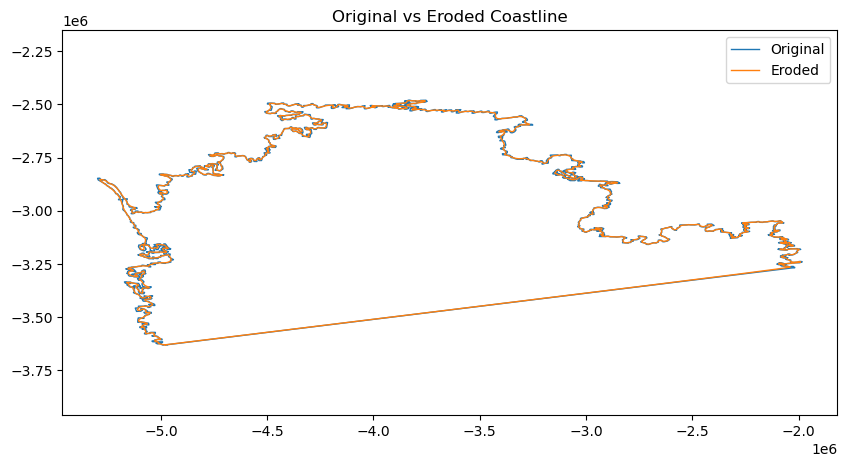

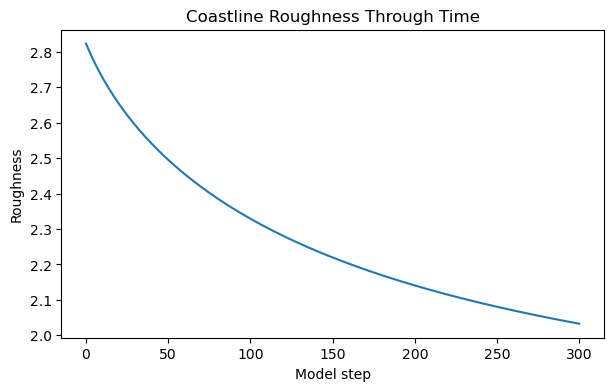

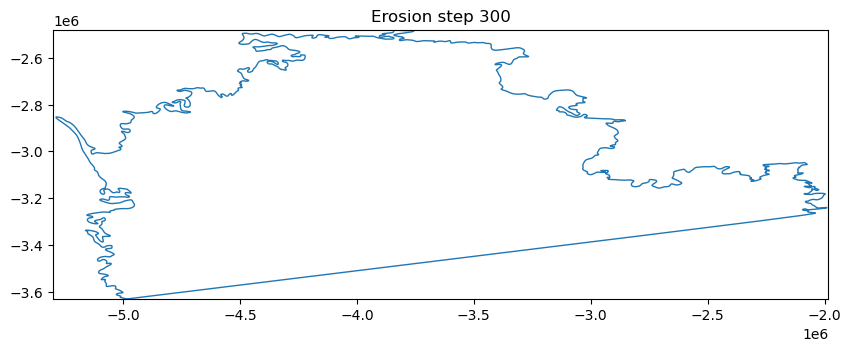

In [13]:

file = "C:/Users/isabe/Downloads/clippedcoast.json"   # change this
gdf = gpd.read_file(file)
gdf.to_file("last_try", driver="GeoJSON")
# -----------------------
# 2. Get all coords for stretch/flip plotting
# -----------------------
all_coords = np.vstack([np.array(g.coords) for g in gdf.geometry])
all_y = all_coords[:, 1]

stretch = 9
y_mean = all_y.mean()

def transform_coords(x, y):
    y_stretched = (y - y_mean) * stretch + y_mean
    x_plot = -y_stretched
    y_plot = x
    return x_plot, y_plot

# -----------------------
# 3. Extract longest coastline
# -----------------------
coastline = max(gdf.geometry, key=lambda g: g.length)

coords = np.array(coastline.coords)
x = coords[:, 0].astype(float)
y = coords[:, 1].astype(float)

# -----------------------
# 4. Close the gap from the start
# -----------------------
if not np.allclose([x[0], y[0]], [x[-1], y[-1]]):
    x = np.append(x, x[0])
    y = np.append(y, y[0])

# -----------------------
# 5. Model settings
# -----------------------
steps = 300
dt = 0.1
k = 0.05
wave_amp = 0.6

n = len(x)
wave_energy = 1 + wave_amp * np.sin(np.linspace(0, 4*np.pi, n))

# -----------------------
# 6. Roughness function
# -----------------------
def roughness(x, y):
    line = LineString(np.column_stack([x, y]))
    return line.length / line.convex_hull.length

# -----------------------
# 7. Erosion step
# -----------------------
def erosion_step(x, y):
    x_lap = np.roll(x, -1) - 2*x + np.roll(x, 1)
    y_lap = np.roll(y, -1) - 2*y + np.roll(y, 1)

    x_new = x + k * wave_energy * x_lap * dt
    y_new = y + k * wave_energy * y_lap * dt

    # keep loop closed exactly
    x_new[-1] = x_new[0]
    y_new[-1] = y_new[0]

    return x_new, y_new

# -----------------------
# 8. Run model
# -----------------------
x_hist = [x.copy()]
y_hist = [y.copy()]
roughness_hist = [roughness(x, y)]

for step in range(steps):
    x, y = erosion_step(x, y)

    x_hist.append(x.copy())
    y_hist.append(y.copy())
    roughness_hist.append(roughness(x, y))

# -----------------------
# 9. Plot original vs eroded
# -----------------------
x0_t, y0_t = transform_coords(x_hist[0], y_hist[0])
x1_t, y1_t = transform_coords(x_hist[-1], y_hist[-1])

plt.figure(figsize=(10, 5))
plt.plot(x0_t, y0_t, label="Original", linewidth=1)
plt.plot(x1_t, y1_t, label="Eroded", linewidth=1)
plt.axis("equal")
plt.legend()
plt.title("Original vs Eroded Coastline")
plt.show()

# -----------------------
# 10. Plot roughness
# -----------------------
plt.figure(figsize=(7, 4))
plt.plot(roughness_hist)
plt.xlabel("Model step")
plt.ylabel("Roughness")
plt.title("Coastline Roughness Through Time")
plt.show()

# -----------------------
# 11. Animation
# -----------------------
fig, ax = plt.subplots(figsize=(10, 5))

x_init, y_init = transform_coords(x_hist[0], y_hist[0])
line, = ax.plot(x_init, y_init, linewidth=1)

ax.set_aspect("equal")

all_tx = []
all_ty = []

for xh, yh in zip(x_hist, y_hist):
    xt, yt = transform_coords(xh, yh)
    all_tx.extend(xt)
    all_ty.extend(yt)

ax.set_xlim(min(all_tx), max(all_tx))
ax.set_ylim(min(all_ty), max(all_ty))

def update(frame):
    xt, yt = transform_coords(x_hist[frame], y_hist[frame])
    line.set_data(xt, yt)
    ax.set_title(f"Erosion step {frame}")
    return line,

ani = FuncAnimation(fig, update, frames=len(x_hist), interval=40)
ani.save("coastline_erosion_stretched_closed.gif", writer="pillow", fps=50)
plt.show()

# -----------------------
# 12. Save final eroded coastline
# -----------------------
eroded_line = LineString(np.column_stack([x_hist[-1], y_hist[-1]]))

out = gpd.GeoDataFrame(
    {"name": ["eroded_coastline"]},
    geometry=[eroded_line],
    crs=gdf.crs
)

out.to_file("eroded_coastline.geojson", driver="GeoJSON")